# 04 — Supervised Classification
### Aral Sea Water/Land Classification — AI4EO Project

This notebook implements two supervised machine learning classifiers trained on
IRIS ground-truth labels, with **spatially separated training and test regions**
to ensure robust evaluation.

| Region | Crop coordinates | Mask file | Purpose |
|--------|-----------------|-----------|---------|
| Training | `[0, 1024, 512, 1536]` | `<year>.npy` | Model training |
| Test | `[1024, 0, 1536, 512]` | `<year>_test.npy` | Independent evaluation |

This spatial separation is important — evaluating on the same region used for
training would give an optimistic accuracy estimate. By using a geographically
distinct patch, we get a more honest assessment of how well the models generalise
across the scene.

**Models:**
- **CNN** (Convolutional Neural Network) — TensorFlow/Keras
- **Random Forest** — Scikit-learn

**Input:** Preprocessed stacks + IRIS masks from both crop regions
**Output:** Trained models, full-scene prediction maps, evaluation metrics

## Step 1 — Mount Drive and set paths

In [15]:
from google.colab import drive
drive.mount('/content/drive')

import os
BASE          = '/content/drive/MyDrive/Claude_aral'
PROCESSED_DIR = f'{BASE}/data/processed'
MASKS_DIR     = f'{BASE}/masks'
FIGURES_DIR   = f'{BASE}/figures'
MODELS_DIR    = f'{BASE}/models'

os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

YEARS        = ['2016', '2022', '2026']
TRAIN_YEAR   = '2016'
RANDOM_STATE = 42

# Spatial crop coordinates
TRAIN_CROP = (0,    1024, 512,  1536)   # row0, col0, row1, col1
TEST_CROP  = (1024, 0,    1536, 512)

print("Paths set.")
print(f"Training crop: rows {TRAIN_CROP[0]}-{TRAIN_CROP[2]}, cols {TRAIN_CROP[1]}-{TRAIN_CROP[3]}")
print(f"Test crop:     rows {TEST_CROP[0]}-{TEST_CROP[2]}, cols {TEST_CROP[1]}-{TEST_CROP[3]}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Paths set.
Training crop: rows 0-512, cols 1024-1536
Test crop:     rows 1024-1536, cols 0-512


## Step 2 — Imports

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             classification_report, accuracy_score)
import joblib
import warnings
warnings.filterwarnings('ignore')

np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

print(f"TensorFlow version: {tf.__version__}")
print("All imports complete.")

TensorFlow version: 2.20.0
All imports complete.


## Step 3 — Patch extraction function

We extract `(3, 3, 6)` patches centred on each labelled pixel — the same
approach used in class for sea ice/lead classification. The function works
for both the training and test crop regions.

In [17]:
def extract_patches_and_labels(year: str, crop: tuple,
                                mask_suffix: str = '',
                                patch_size: int = 3):
    """
    Extract (patch_size, patch_size, 6) patches and binary labels
    from a given crop region.

    Parameters
    ----------
    year        : '2016', '2022', or '2026'
    crop        : (row0, col0, row1, col1) crop coordinates
    mask_suffix : '' for training masks, '_test' for test masks
    patch_size  : spatial context window (default 3x3)

    Label logic:
      IRIS mask == 1 AND NDWI > 0  → Water  (label 1)
      IRIS mask == 0 AND NDWI < -0.05 → Land (label 0)
      All other pixels              → excluded
    """
    R0, C0, R1, C1 = crop

    stack    = np.load(f'{PROCESSED_DIR}/{year}_stack.npy')
    validity = np.load(f'{PROCESSED_DIR}/{year}_validity.npy')
    mask     = np.load(f'{MASKS_DIR}/{year}{mask_suffix}.npy')

    stack_crop    = stack[R0:R1, C0:C1, :]
    validity_crop = validity[R0:R1, C0:C1]

    H, W, C = stack_crop.shape
    pad     = patch_size // 2

    ndwi      = stack_crop[:, :, 5]
    label_map = np.full((H, W), -1, dtype=np.int8)
    label_map[mask == 1]                                       = 1  # Water
    label_map[(mask == 0) & (ndwi < -0.05) & validity_crop]   = 0  # Land

    print(f"  [{year}] {mask_suffix or 'train'} crop — "
          f"Water: {(label_map==1).sum():,}, "
          f"Land: {(label_map==0).sum():,}, "
          f"Excluded: {(label_map==-1).sum():,}")

    padded  = np.pad(stack_crop, ((pad, pad), (pad, pad), (0, 0)),
                     mode='reflect')
    patches = []
    labels  = []

    ys, xs = np.where(label_map >= 0)
    for y, x in zip(ys, xs):
        patch = padded[y:y+patch_size, x:x+patch_size, :]
        patches.append(patch)
        labels.append(label_map[y, x])

    patches = np.array(patches, dtype=np.float32)
    labels  = np.array(labels,  dtype=np.int8)

    print(f"  Total patches: {len(patches):,}")
    return patches, labels

## Step 4 — Build training dataset

We extract patches from the **training crop** of the 2016 scene, balance
the classes, and split into train/validation sets (90/10).

In [18]:
def balance_classes(patches, labels, seed=42):
    """Undersample majority class to match minority class count."""
    idx_w = np.where(labels == 1)[0]
    idx_l = np.where(labels == 0)[0]
    n_min = min(len(idx_w), len(idx_l))
    rng   = np.random.default_rng(seed)
    idx_w = rng.choice(idx_w, n_min, replace=False)
    idx_l = rng.choice(idx_l, n_min, replace=False)
    combined = np.concatenate([idx_w, idx_l])
    rng.shuffle(combined)
    return patches[combined], labels[combined]


print("Extracting training patches from 2016 training crop...")
patches_train, labels_train = extract_patches_and_labels(
    TRAIN_YEAR, TRAIN_CROP, mask_suffix='')

patches_bal, labels_bal = balance_classes(patches_train, labels_train,
                                          seed=RANDOM_STATE)

unique, counts = np.unique(labels_bal, return_counts=True)
print(f"Balanced: {dict(zip(unique.tolist(), counts.tolist()))}")

X_train, X_val, y_train, y_val = train_test_split(
    patches_bal, labels_bal,
    test_size=0.1,
    random_state=RANDOM_STATE,
    stratify=labels_bal
)
print(f"X_train: {X_train.shape}, X_val: {X_val.shape}")

np.save(f'{PROCESSED_DIR}/X_train.npy', X_train)
np.save(f'{PROCESSED_DIR}/X_val.npy',   X_val)
np.save(f'{PROCESSED_DIR}/y_train.npy', y_train)
np.save(f'{PROCESSED_DIR}/y_val.npy',   y_val)
print("Training arrays saved.")

Extracting training patches from 2016 training crop...
  [2016] train crop — Water: 157,326, Land: 54,367, Excluded: 50,451
  Total patches: 211,693
Balanced: {0: 54367, 1: 54367}
X_train: (97860, 3, 3, 6), X_val: (10874, 3, 3, 6)
Training arrays saved.


## Step 5 — Build spatially independent test dataset

We extract patches from the **test crop** — a completely different region
of the scene that was not used during training. This gives a genuine measure
of how well the models generalise spatially.

In [19]:
print("Extracting test patches from 2016 test crop...")
patches_test, labels_test = extract_patches_and_labels(
    TRAIN_YEAR, TEST_CROP, mask_suffix='_test')

# Balance test set too for fair evaluation
patches_test_bal, labels_test_bal = balance_classes(
    patches_test, labels_test, seed=RANDOM_STATE)

unique, counts = np.unique(labels_test_bal, return_counts=True)
print(f"Balanced test set: {dict(zip(unique.tolist(), counts.tolist()))}")

X_test = patches_test_bal
y_test = labels_test_bal

np.save(f'{PROCESSED_DIR}/X_test.npy', X_test)
np.save(f'{PROCESSED_DIR}/y_test.npy', y_test)
print(f"X_test: {X_test.shape}")
print("Test arrays saved.")

Extracting test patches from 2016 test crop...
  [2016] _test crop — Water: 175,951, Land: 40,691, Excluded: 45,502
  Total patches: 216,642
Balanced test set: {0: 40691, 1: 40691}
X_test: (81382, 3, 3, 6)
Test arrays saved.


## Step 6 — CNN model

Same architecture as used in class for sea ice/lead classification,
adapted for our 6-channel Sentinel-2 input.

In [20]:
model_cnn = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu',
                  input_shape=(3, 3, 6), padding='SAME'),
    layers.Conv2D(64, (3, 3), activation='relu', padding='SAME'),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])

model_cnn.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model_cnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 32)       │         1,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 3, 3, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 57,249 (223.63 KB)

 Trainable params: 57,249 (223.63 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

history_cnn = model_cnn.fit(
    X_train, y_train,
    epochs=50,
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
    verbose=1
)

model_cnn.save(f'{MODELS_DIR}/cnn_aral.h5')
print("CNN saved.")

Epoch 1/50
1530/1530 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.6862 - loss: 0.5463 - val_accuracy: 0.6879 - val_loss: 0.5458
Epoch 2/50
1530/1530 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.6968 - loss: 0.5332 - val_accuracy: 0.6936 - val_loss: 0.5365
Epoch 3/50
1530/1530 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.7021 - loss: 0.5258 - val_accuracy: 0.6971 - val_loss: 0.5347
Epoch 4/50
1530/1530 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.7089 - loss: 0.5198 - val_accuracy: 0.7090 - val_loss: 0.5282
Epoch 5/50
1530/1530 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.7194 - loss: 0.5134 - val_accuracy: 0.7100 - val_loss: 0.5324
Epoch 6/50
1530/1530 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.7271 - loss: 0.5062 - val_accuracy: 0.7196 - val_loss: 0.5218
Epoch 7/50
1530/1530 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.7333 - loss: 0.4995 - val_accuracy: 0.7237 - val_loss: 0.5208
Epoch 8/50
1530/1530 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.7374 - loss: 0

CNN saved.


## Step 7 — CNN training curves

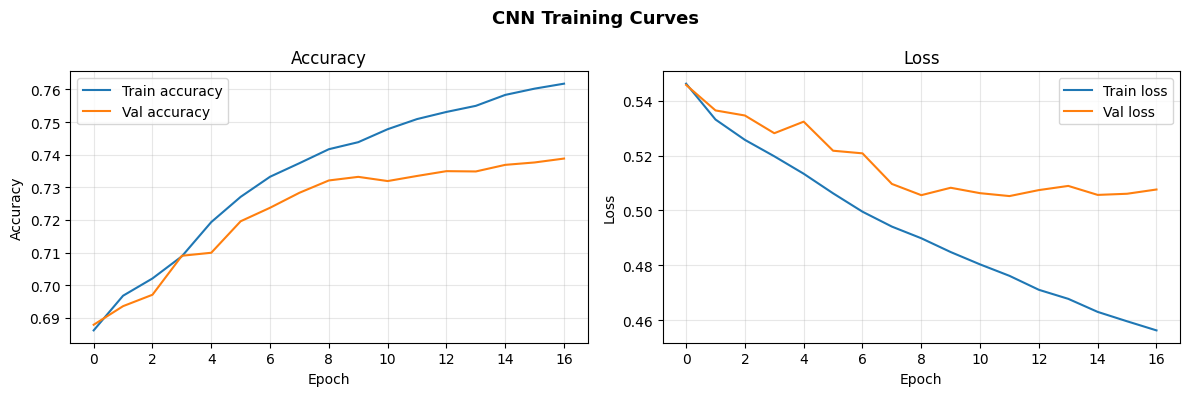

Figure saved: /content/drive/MyDrive/Claude_aral/figures/training_curves_cnn.png


In [22]:
def plot_training_curves(history, title='CNN'):
    acc      = history.history['accuracy']
    val_acc  = history.history['val_accuracy']
    loss     = history.history['loss']
    val_loss = history.history['val_loss']
    epochs   = range(len(acc))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f'{title} Training Curves', fontsize=13, fontweight='bold')

    ax1.plot(epochs, acc,     label='Train accuracy')
    ax1.plot(epochs, val_acc, label='Val accuracy')
    ax1.set_title('Accuracy'); ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy'); ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2.plot(epochs, loss,     label='Train loss')
    ax2.plot(epochs, val_loss, label='Val loss')
    ax2.set_title('Loss'); ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss'); ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    out = f'{FIGURES_DIR}/training_curves_cnn.png'
    fig.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Figure saved: {out}')

plot_training_curves(history_cnn, title='CNN')

## Step 8 — CNN evaluation on spatially independent test set

The test set comes from a different geographic region than the training data,
giving a genuine assessment of spatial generalisation.

CNN Test Accuracy (spatially independent): 61.38%

              precision    recall  f1-score   support

        Land       0.63      0.54      0.58     40691
       Water       0.60      0.69      0.64     40691

    accuracy                           0.61     81382
   macro avg       0.62      0.61      0.61     81382
weighted avg       0.62      0.61      0.61     81382



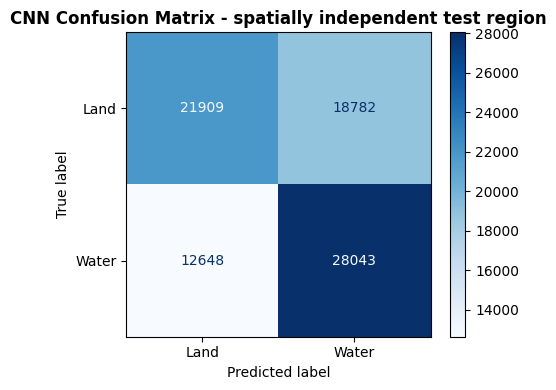

In [23]:
y_pred_cnn_prob = model_cnn.predict(X_test, verbose=0).flatten()
y_pred_cnn      = (y_pred_cnn_prob > 0.5).astype(int)

cnn_accuracy = accuracy_score(y_test, y_pred_cnn)
print(f"CNN Test Accuracy (spatially independent): {cnn_accuracy*100:.2f}%")
print()
print(classification_report(y_test, y_pred_cnn,
                            target_names=['Land', 'Water']))

cm_cnn = confusion_matrix(y_test, y_pred_cnn)
disp   = ConfusionMatrixDisplay(confusion_matrix=cm_cnn,
                                display_labels=['Land', 'Water'])
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(cmap='Blues', values_format='d', ax=ax)
ax.set_title('CNN Confusion Matrix - spatially independent test region',
             fontweight='bold')
plt.tight_layout()
fig.savefig(f'{FIGURES_DIR}/confusion_matrix_cnn.png', dpi=150,
            bbox_inches='tight')
plt.show()

## Step 9 — Random Forest

In [24]:
X_train_rf = X_train.reshape(X_train.shape[0], -1)
X_test_rf  = X_test.reshape(X_test.shape[0], -1)

print(f"Random Forest input shape: {X_train_rf.shape}")

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_model.fit(X_train_rf, y_train)
joblib.dump(rf_model, f'{MODELS_DIR}/random_forest_aral.pkl')
print("Random Forest trained and saved.")

Random Forest input shape: (97860, 54)
Random Forest trained and saved.


## Step 10 — Random Forest evaluation

Random Forest Test Accuracy (spatially independent): 61.06%

              precision    recall  f1-score   support

        Land       0.65      0.49      0.56     40691
       Water       0.59      0.73      0.65     40691

    accuracy                           0.61     81382
   macro avg       0.62      0.61      0.60     81382
weighted avg       0.62      0.61      0.60     81382



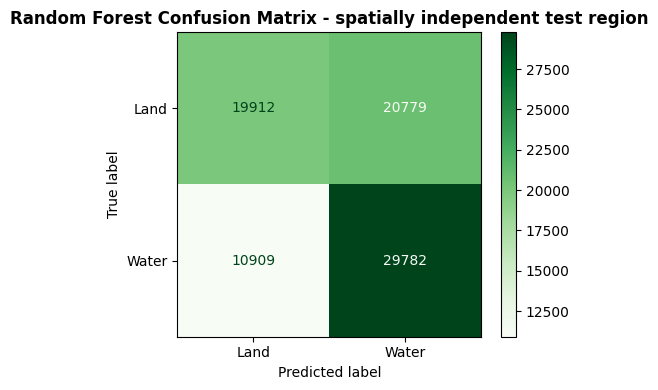

In [25]:
y_pred_rf = rf_model.predict(X_test_rf)

rf_accuracy = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Test Accuracy (spatially independent): {rf_accuracy*100:.2f}%")
print()
print(classification_report(y_test, y_pred_rf,
                            target_names=['Land', 'Water']))

cm_rf = confusion_matrix(y_test, y_pred_rf)
disp  = ConfusionMatrixDisplay(confusion_matrix=cm_rf,
                               display_labels=['Land', 'Water'])
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(cmap='Greens', values_format='d', ax=ax)
ax.set_title('Random Forest Confusion Matrix - spatially independent test region',
             fontweight='bold')
plt.tight_layout()
fig.savefig(f'{FIGURES_DIR}/confusion_matrix_rf.png', dpi=150,
            bbox_inches='tight')
plt.show()

## Step 11 — Full-scene prediction for all years

Both models are applied to every valid pixel across all three years to
produce the classification maps needed for the temporal drawdown analysis.

In [27]:
def predict_full_scene(year: str, patch_size: int = 3):
    """Apply both models to every valid pixel in the full scene."""
    stack    = np.load(f'{PROCESSED_DIR}/{year}_stack.npy')
    validity = np.load(f'{PROCESSED_DIR}/{year}_validity.npy')
    H, W, C  = stack.shape
    pad      = patch_size // 2

    padded  = np.pad(stack, ((pad, pad), (pad, pad), (0, 0)), mode='reflect')
    ys, xs  = np.where(validity)
    n_valid = len(ys)
    print(f"[{year}] Predicting {n_valid} valid pixels...")

    BATCH     = 50_000
    cnn_preds = np.zeros(n_valid, dtype=np.float32)
    rf_preds  = np.zeros(n_valid, dtype=np.int8)

    for start in range(0, n_valid, BATCH):
        end   = min(start + BATCH, n_valid)
        batch = np.array([
            padded[y:y+patch_size, x:x+patch_size, :]
            for y, x in zip(ys[start:end], xs[start:end])
        ], dtype=np.float32)

        cnn_preds[start:end] = model_cnn.predict(
            batch, verbose=0).flatten()
        rf_preds[start:end]  = rf_model.predict(
            batch.reshape(len(batch), -1))

        if (start // BATCH) % 5 == 0:
            print(f"  Processed {end} / {n_valid}...")

    cnn_map = np.full((H, W), -1, dtype=np.float32)
    rf_map  = np.full((H, W), -1, dtype=np.int8)
    cnn_map[validity] = (cnn_preds > 0.5).astype(np.float32)
    rf_map[validity]  = rf_preds

    water_cnn = (cnn_map == 1).sum()
    water_rf  = (rf_map  == 1).sum()
    print(f"  CNN water: {water_cnn} ({water_cnn/n_valid*100:.1f}%)")
    print(f"  RF  water: {water_rf} ({water_rf/n_valid*100:.1f}%)")

    np.save(f'{PROCESSED_DIR}/{year}_cnn_labels.npy', cnn_map)
    np.save(f'{PROCESSED_DIR}/{year}_rf_labels.npy',  rf_map)
    return cnn_map, rf_map


cnn_maps = {}
rf_maps  = {}
for year in YEARS:
    print(f"\n--- {year} ---")
    cnn_map, rf_map = predict_full_scene(year)
    cnn_maps[year] = cnn_map
    rf_maps[year]  = rf_map

print("Full-scene prediction complete.")


--- 2016 ---
[2016] Predicting 1966890 valid pixels...
  Processed 50000 / 1966890...
  Processed 300000 / 1966890...
  Processed 550000 / 1966890...
  Processed 800000 / 1966890...
  Processed 1050000 / 1966890...
  Processed 1300000 / 1966890...
  Processed 1550000 / 1966890...
  Processed 1800000 / 1966890...
  CNN water: 1399389 (71.1%)
  RF  water: 1408844 (71.6%)

--- 2022 ---
[2022] Predicting 1966890 valid pixels...
  Processed 50000 / 1966890...
  Processed 300000 / 1966890...
  Processed 550000 / 1966890...
  Processed 800000 / 1966890...
  Processed 1050000 / 1966890...
  Processed 1300000 / 1966890...
  Processed 1550000 / 1966890...
  Processed 1800000 / 1966890...
  CNN water: 1451278 (73.8%)
  RF  water: 1494494 (76.0%)

--- 2026 ---
[2026] Predicting 1966890 valid pixels...
  Processed 50000 / 1966890...
  Processed 300000 / 1966890...
  Processed 550000 / 1966890...
  Processed 800000 / 1966890...
  Processed 1050000 / 1966890...
  Processed 1300000 / 1966890...
  Pro

## Step 12 — Visualise predictions

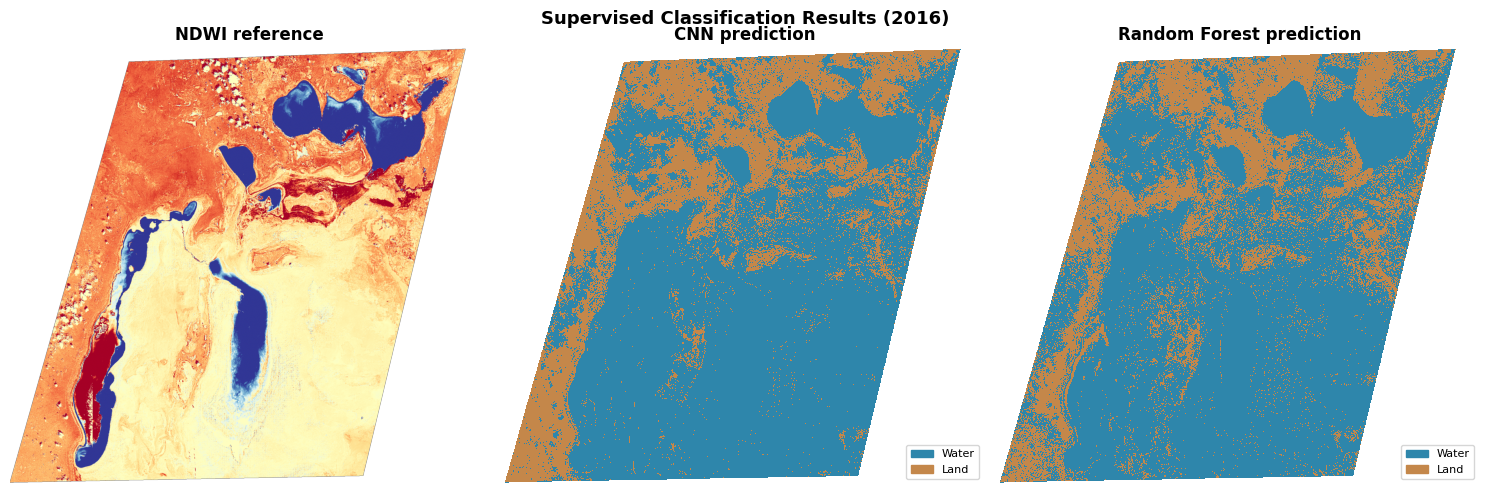

Figure saved: /content/drive/MyDrive/Claude_aral/figures/supervised_2016.png


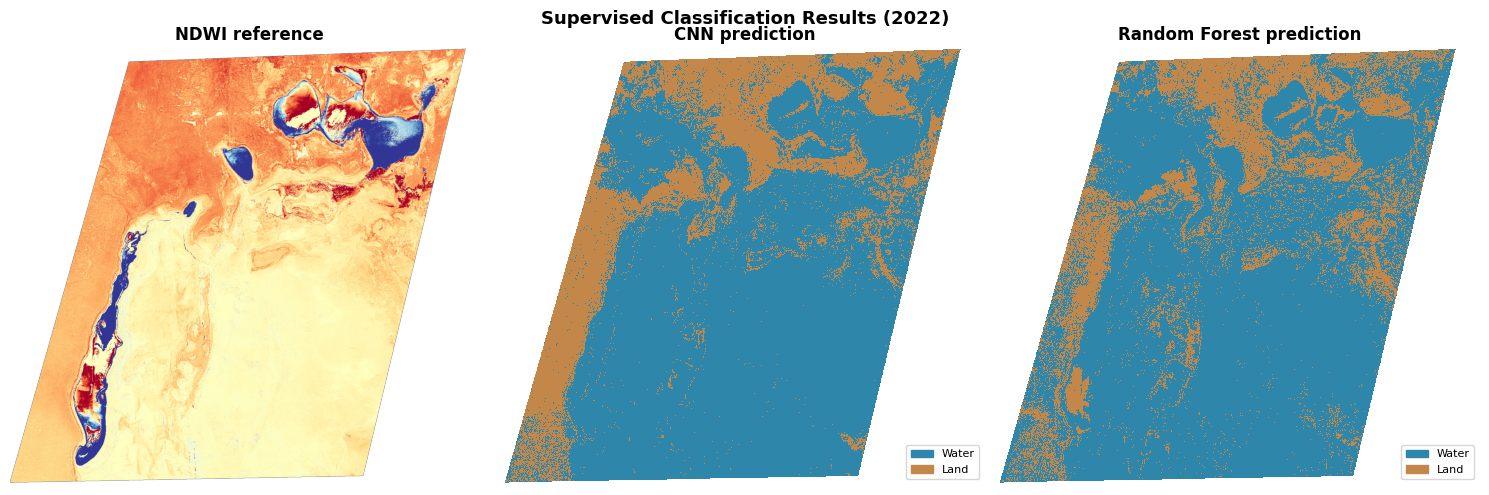

Figure saved: /content/drive/MyDrive/Claude_aral/figures/supervised_2022.png


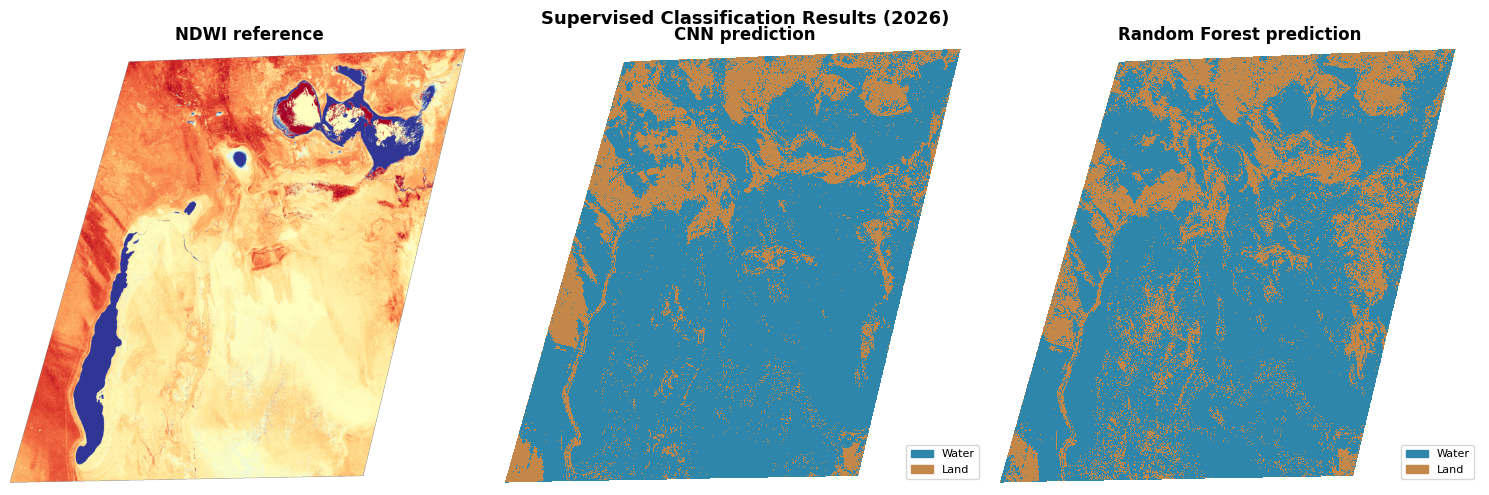

Figure saved: /content/drive/MyDrive/Claude_aral/figures/supervised_2026.png


In [28]:
WATER_CMAP     = ListedColormap(['#C4874A', '#2E86AB'])
patches_legend = [mpatches.Patch(color='#2E86AB', label='Water'),
                  mpatches.Patch(color='#C4874A', label='Land')]

for year in YEARS:
    stack    = np.load(f'{PROCESSED_DIR}/{year}_stack.npy')
    validity = np.load(f'{PROCESSED_DIR}/{year}_validity.npy')

    ndwi = stack[:, :, 5].copy(); ndwi[~validity] = np.nan

    cnn_d = cnn_maps[year].copy().astype(float); cnn_d[~validity] = np.nan
    rf_d  = rf_maps[year].copy().astype(float);  rf_d[~validity]  = np.nan

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(f'Supervised Classification Results ({year})',
                 fontsize=13, fontweight='bold')

    axes[0].imshow(ndwi, cmap='RdYlBu', vmin=-0.5, vmax=0.5)
    axes[0].set_title('NDWI reference', fontweight='bold')
    axes[0].axis('off')

    axes[1].imshow(cnn_d, cmap=WATER_CMAP, vmin=0, vmax=1,
                   interpolation='nearest')
    axes[1].set_title('CNN prediction', fontweight='bold')
    axes[1].axis('off')
    axes[1].legend(handles=patches_legend, loc='lower right', fontsize=8)

    axes[2].imshow(rf_d, cmap=WATER_CMAP, vmin=0, vmax=1,
                   interpolation='nearest')
    axes[2].set_title('Random Forest prediction', fontweight='bold')
    axes[2].axis('off')
    axes[2].legend(handles=patches_legend, loc='lower right', fontsize=8)

    plt.tight_layout()
    out = f'{FIGURES_DIR}/supervised_{year}.png'
    fig.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Figure saved: {out}')

## Step 13 — Water area estimates

Water area counted within the training crop only for comparability
with unsupervised methods.

In [29]:
PIXEL_SIZE_KM  = 318 / 1766
R0, C0, R1, C1 = TRAIN_CROP

print(f"{'Year':<6} {'CNN (km2)':>12} {'RF (km2)':>12}")
print("-" * 32)

supervised_results = {}
for year in YEARS:
    validity = np.load(f'{PROCESSED_DIR}/{year}_validity.npy')
    val_crop = validity[R0:R1, C0:C1]

    cnn_w = ((cnn_maps[year][R0:R1, C0:C1] == 1) & val_crop).sum()              * PIXEL_SIZE_KM**2
    rf_w  = ((rf_maps[year][R0:R1, C0:C1]  == 1) & val_crop).sum()              * PIXEL_SIZE_KM**2

    supervised_results[year] = {'cnn': cnn_w, 'rf': rf_w}
    print(f"{year:<6} {cnn_w:>12.1f} {rf_w:>12.1f}")

print()
for method in ['cnn', 'rf']:
    change = supervised_results['2026'][method] - supervised_results['2016'][method]
    pct    = change / supervised_results['2016'][method] * 100
    print(f"{method.upper()}: 2016 to 2026 = {change:+.1f} km2 ({pct:+.1f}%)")

Year      CNN (km2)     RF (km2)
--------------------------------
2016         4813.2       5151.2
2022         4735.9       4867.0
2026         5175.9       4643.0

CNN: 2016 to 2026 = +362.6 km2 (+7.5%)
RF: 2016 to 2026 = -508.2 km2 (-9.9%)


## Step 14 — Temporal drawdown curve

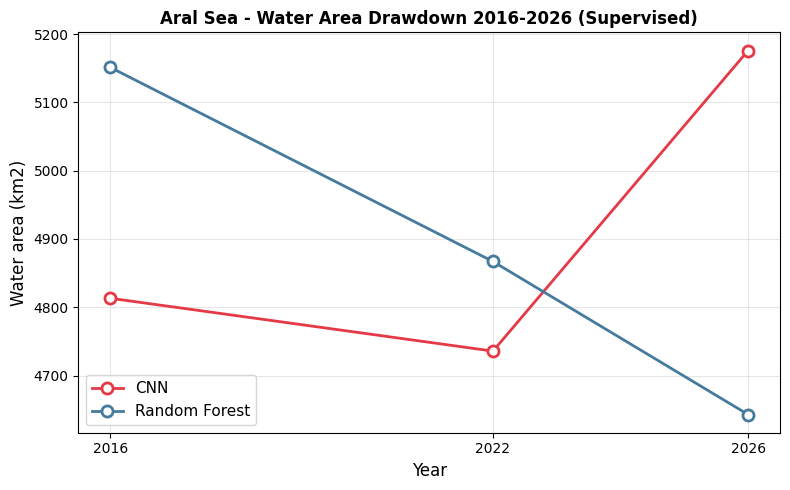

Figure saved: /content/drive/MyDrive/Claude_aral/figures/drawdown_supervised.png


In [30]:
import matplotlib.pyplot as plt

year_vals = [int(y) for y in YEARS]
methods   = ['cnn', 'rf']
colours   = ['#E63946', '#457B9D']
labels    = ['CNN', 'Random Forest']

fig, ax = plt.subplots(figsize=(8, 5))

for method, colour, label in zip(methods, colours, labels):
    areas = [supervised_results[y][method] for y in YEARS]
    ax.plot(year_vals, areas, 'o-', color=colour, label=label,
            linewidth=2, markersize=8, markerfacecolor='white',
            markeredgewidth=2)

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Water area (km2)', fontsize=12)
ax.set_title('Aral Sea - Water Area Drawdown 2016-2026 (Supervised)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xticks(year_vals)

plt.tight_layout()
out = f'{FIGURES_DIR}/drawdown_supervised.png'
fig.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Figure saved: {out}')

## Summary

This notebook trained CNN and Random Forest classifiers on 2016 IRIS labels
from the training crop, and evaluated them on a **spatially independent**
test crop labelled separately in IRIS.

**Key outputs saved:**
- `models/cnn_aral.h5` — trained CNN
- `models/random_forest_aral.pkl` — trained Random Forest
- `data/processed/<year>_cnn_labels.npy` — CNN prediction maps
- `data/processed/<year>_rf_labels.npy` — RF prediction maps
- Confusion matrices, training curves, classification maps, drawdown curve

**Points to discuss in your report:**
- Spatial generalisation: models trained on one region, tested on another
- Which model performs better on the independent test set?
- How do supervised drawdown trends compare to unsupervised methods?
- The CNN was trained only on 2016 labels — how well does it generalise to 2022 and 2026?

**Next:** `05_gp_uncertainty.ipynb` — Gaussian Process uncertainty quantification.